In [23]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

In [ ]:
# Noisy Sine wave Seqeuence Generation

class Data(d2l.DataModule):
    
    def __init__(
        self,
        batch_size: int = 16,
        T: int = 1000,
        num_train: int = 600,
        tau: int = 4,
    ) -> None:
        
        self.save_hyperparameters()
        
        # [1, 2, ..., 1000]
        self.time: torch.Tensor = torch.arange(
            1,
            T + 1,
            dtype=torch.float32,
        )
        
        # x = sin([0.01, 0.02, ... , 10]) + noise
        self.x: torch.Tensor = (
            torch.sin(
                0.01 * self.time
            )
            + torch.randn(T) * 0.2
        )


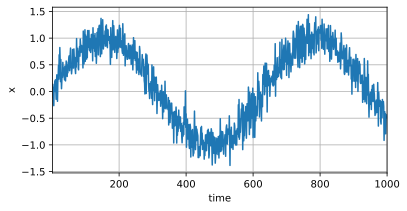

In [25]:
data = Data()

d2l.plot(
    data.time,
    data.x,
    xlabel="time",
    ylabel="x",
    xlim=[1, 1000],
    figsize=(6, 3),
)

In [26]:
# Sliding Window Dataset 생성

def data_get_dataloader(
    self: Data,
    train: bool,
):

    shifted_sequences: list[
        torch.Tensor
    ] = [
        self.x[
            i : self.T - self.tau + i
        ]
        for i in range(self.tau)
    ]
    
    self.features: torch.Tensor = (
        torch.stack(
            shifted_sequences,
            dim=1,
        )
    )
    
    self.labels: torch.Tensor = (
        self.x[self.tau:].reshape(
            -1,
            1,
        )
    )
    
    indices = (
        slice(
            0,
            self.num_train,
        )
        if train
        else slice(
            self.num_train,
            None,
        )
    )
    
    return self.get_tensorloader(
        (
            self.features,
            self.labels,
        ),
        train,
        indices,
    )
    
    
Data.get_dataloader = (
    data_get_dataloader
)

In [27]:
# Sliding Window Shape 확인

train_dataloader = data.get_dataloader(
    train=True,
)

X, y = next(
    iter(train_dataloader)
)

print(
    "All feature shape:",
    tuple(data.features.shape),
)

print(
    "All label shape:",
    tuple(data.labels.shape),
)

print(
    "Batch X shape:",
    tuple(X.shape),
)

print(
    "Batch y shape:",
    tuple(y.shape),
)

print(
    "\nFirst feature:",
    data.features[0],
)

print(
    "First label:",
    data.labels[0],
)

All feature shape: (996, 4)
All label shape: (996, 1)
Batch X shape: (16, 4)
Batch y shape: (16, 1)

First feature: tensor([-0.0037,  0.1347, -0.0997, -0.1360])
First label: tensor([-0.2652])


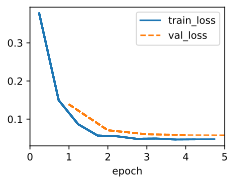

In [30]:
# Linear AutoRegressive Model Training

model = d2l.LinearRegression(
    lr=1e-2,
)

trainer = d2l.Trainer(
    max_epochs=5,
)

trainer.fit(
    model,
    data,
)